In [28]:
# import librerias
import cv2
import numpy as np
import matplotlib.pyplot as plt
import glob

### Parte 1: 
Para imágenes en /assets/white_patch

1 - Implementar el algoritmo White Patch para librarnos de las diferencias de color de iluminación.

2 - Mostrar los resultados obtenidos y analizar las posibles fallas (si es que las hay) en el caso de
White patch.

In [38]:
# Obtención de imagenes dentro de white_patch 
img_list = sorted(glob.glob("../assets/white_patch/*"))

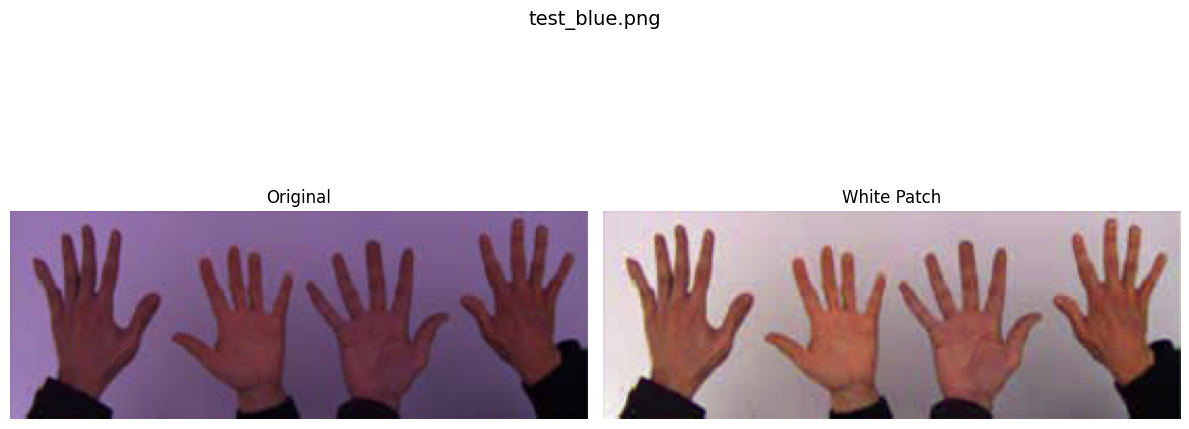

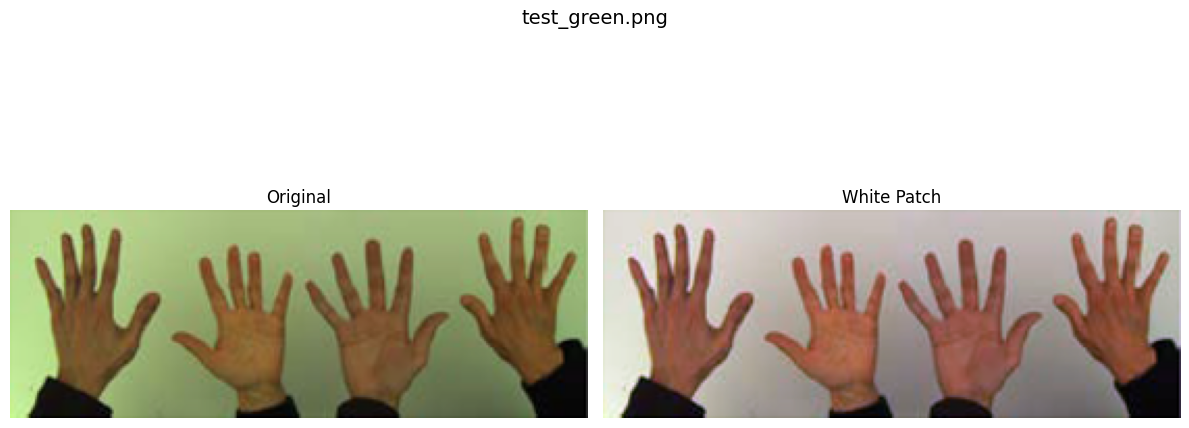

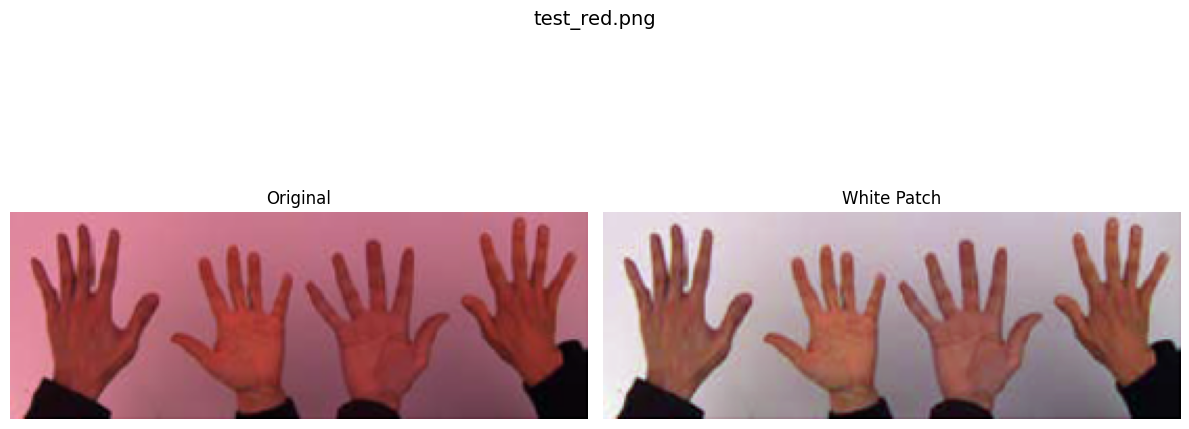

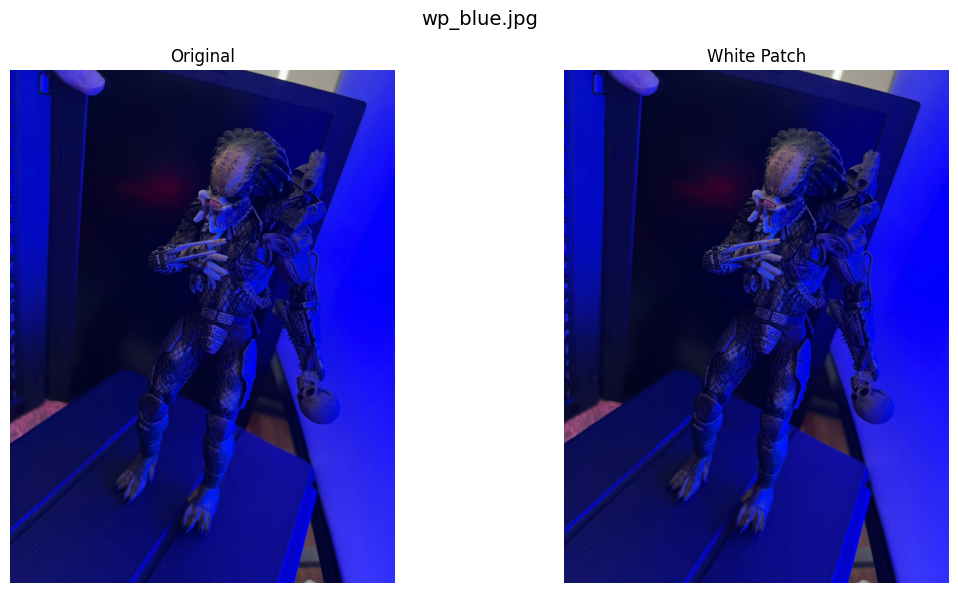

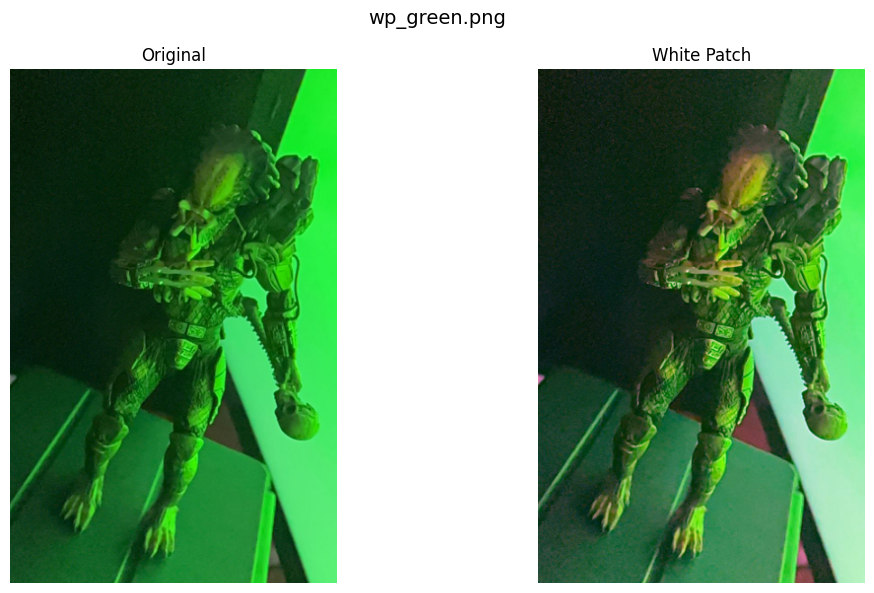

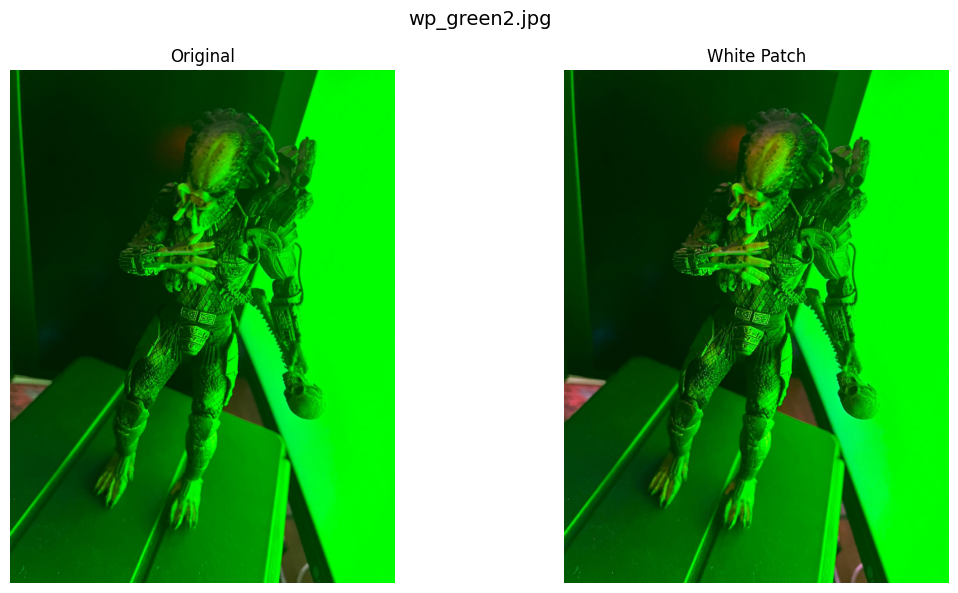

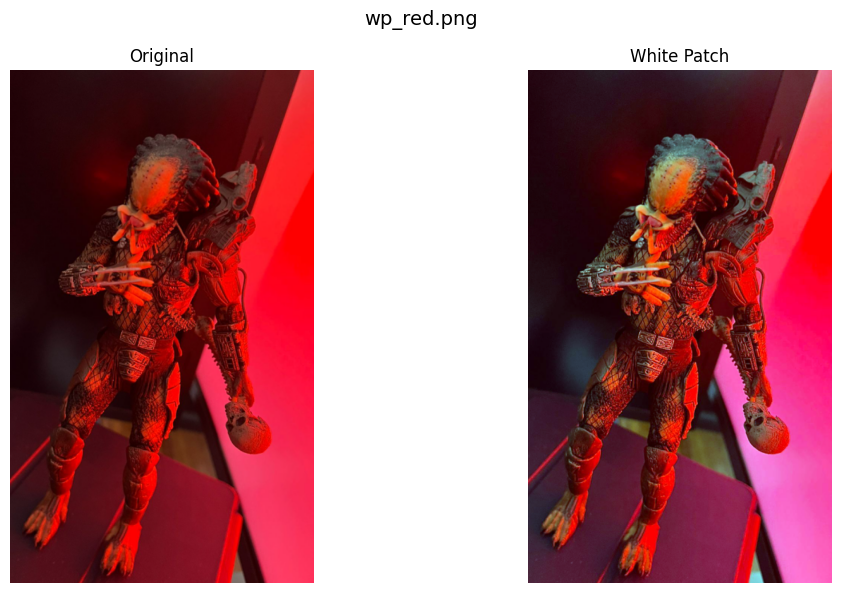

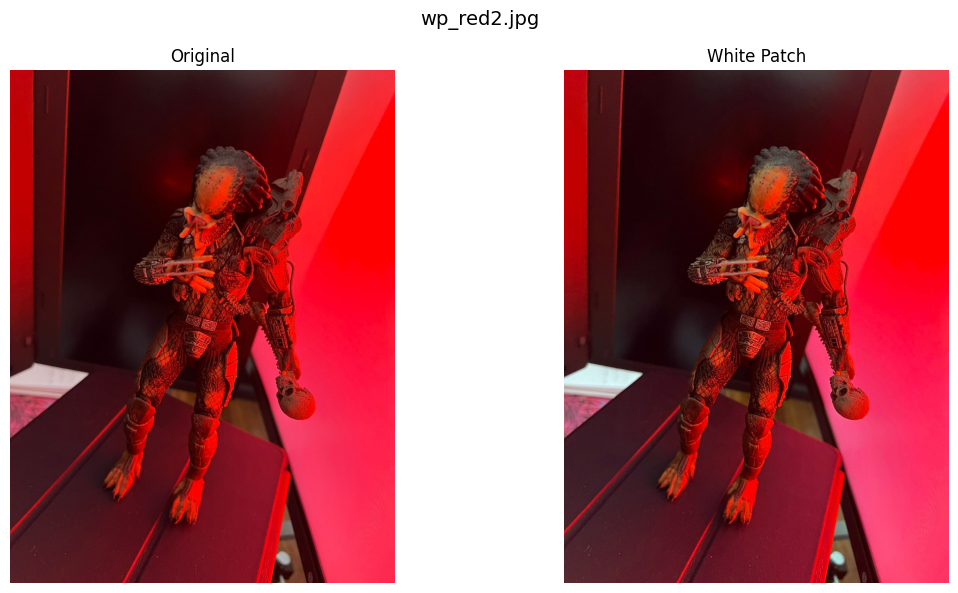

In [40]:
for path in img_list:
    # Para cada canal RGB, se obtiene valor máximo y se calcula 255/max. Luego se multiplican los canales por el factor. 
    # Calculo de valores máximos por canal. 
    img = cv2.imread(path)
    # De BGR a RGB
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    im_r, im_g, im_b = cv2.split(img)

    # Obtener valor máximo de matríz r_channel 
    r_max = np.max(im_r)
    # Calculo de factor de corrección 
    r_factor = 255 / r_max

    # Obtener valor máximo de matríz g_channel 
    g_max = np.max(im_g)
    # Calculo de factor de corrección 
    g_factor = 255 / g_max

    # Obtener valor máximo de matríz b_channel 
    b_max = np.max(im_b)
    # Calculo de factor de corrección 
    b_factor = 255 / b_max

    '''
    # print valores 
    print(f"Valor máximo del canal R: {r_max}")
    print(f"Valor máximo del canal G: {g_max}")
    print(f"Valor máximo del canal B: {b_max}")

    # print 
    print(f"Factor de corrección para el canal R: {r_factor}")
    print(f"Factor de corrección para el canal G: {g_factor}")
    print(f"Factor de corrección para el canal B: {b_factor}")
    '''

    # Aplicación de factor 
    img_processed =cv2.merge((np.uint8(im_r * r_factor), np.uint8(im_g * g_factor), np.uint8(im_b * b_factor)))

    fig, axs = plt.subplots(1, 2, figsize=(12, 6))
    axs[0].imshow(img); axs[0].set_title("Original"); axs[0].axis("off")
    axs[1].imshow(img_processed); axs[1].set_title("White Patch"); axs[1].axis("off")

    fig.suptitle(path.split("/")[-1], fontsize=14)
    plt.tight_layout()
    plt.show()

### Parte 2
